# HYPOTHESIS

Home court advantage, rest days, and star or key player availability
are all associated with higher win probability with all independently playing their own rolls in the outcome of NBA games.

What I will test:
 | # | Hypothesis | Method |
|---|-----------|--------|
| H1 | Teams playing at home win more often than expected| Compare home vs away win rates from 5 seasons |
| H2 | Teams with more rest days win more often than fatigued teams | Compare win rates on 0 rest days vs 2 or more rest days |
| H3 | Teams missing star players win less often than when fully healthy | Compare the wolves win rate with vs without key players |

---
## Phase 1: Pulling data from NBA API
---
### Get team game logs from 3-5 past seasons
> Figuring this out wasnt too hard I just followed an online forum, syntax is a bit different from Labs but the same structure is there, just adding it to a data folder

In [102]:
from nba_api.stats.endpoints import leaguegamelog, leaguestandings, commonteamroster, playergamelog
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

seasons = ["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
all_games = []

for season in seasons:
    games = leaguegamelog.LeagueGameLog(season=season)
    df = games.get_data_frames()[0]
    df["SEASON"] = season
    all_games.append(df)

games_df = pd.concat(all_games, ignore_index=True)
games_df.to_csv("data/all_games.csv", index=False)
print(f"Total games: {len(games_df)}")


Total games: 12300


### Now pull specific season stats for each team

In [ ]:
standings = leaguestandings.LeagueStandings(season="2023-24")
standings_df = standings.get_data_frames()[0]
standings_df.to_csv("data/standings.csv", index=False)
print(standings_df)

   LeagueID SeasonID      TeamID       TeamCity       TeamName Conference  \
0        00    22023  1610612760  Oklahoma City        Thunder       West   
1        00    22023  1610612738         Boston        Celtics       East   
2        00    22023  1610612743         Denver        Nuggets       West   
3        00    22023  1610612752       New York         Knicks       East   
4        00    22023  1610612750      Minnesota   Timberwolves       West   
5        00    22023  1610612749      Milwaukee          Bucks       East   
6        00    22023  1610612739      Cleveland      Cavaliers       East   
7        00    22023  1610612746             LA       Clippers       West   
8        00    22023  1610612753        Orlando          Magic       East   
9        00    22023  1610612742         Dallas      Mavericks       West   
10       00    22023  1610612756        Phoenix           Suns       West   
11       00    22023  1610612754        Indiana         Pacers       East   

### Now get player availability data such as injuries and active lineups


In [ ]:
# Example: get Timberwolves roster
wolves_roster = commonteamroster.CommonTeamRoster(team_id=1610612750, season="2023-24")
roster_df = wolves_roster.get_data_frames()[0]
print(roster_df)


        TeamID SEASON LeagueID                    PLAYER      NICKNAME  \
0   1610612750   2023       00              Jaylen Clark        Jaylen   
1   1610612750   2023       00             Kyle Anderson          Kyle   
2   1610612750   2023       00           Jaden McDaniels         Jaden   
3   1610612750   2023       00           Anthony Edwards       Anthony   
4   1610612750   2023       00         Jordan McLaughlin        Jordan   
5   1610612750   2023       00         Wendell Moore Jr.       Wendell   
6   1610612750   2023       00               Josh Minott          Josh   
7   1610612750   2023       00  Nickeil Alexander-Walker       Nickeil   
8   1610612750   2023       00               Mike Conley          Mike   
9   1610612750   2023       00                  Naz Reid           Naz   
10  1610612750   2023       00               Daishen Nix       Daishen   
11  1610612750   2023       00              Monté Morris         Monté   
12  1610612750   2023       00        

### Filter games for the Timberwolves case
> I will use two key players for simplicity of the case, two players who make impact on different sides of the court to get a good sense of data here, I will pick Rudy Gobert for his strong defensive presence and Anthony Edwards for his play making and scoring ability

**Note** The specific games were already saved, the below cell is just reading the CSV files, I had hit the API limit so continuosly hitting the API was giving me errors

In [18]:
ant = pd.read_csv("data/ant_games.csv")
gobert = pd.read_csv("data/gobert_games.csv")
print(f"ANT games: {len(ant)} | Gobert games: {len(gobert)}")

ANT games: 370 | Gobert games: 360


---
## Phase 2: Cleaning my data from NBA API
---
### Loading and visualizing

In [19]:

df = pd.read_csv("data/all_games.csv")


print(df.shape)     
print(df.dtypes)       
print(df.isnull().sum())
print(df.head())

(12300, 30)
SEASON_ID              int64
TEAM_ID                int64
TEAM_ABBREVIATION     object
TEAM_NAME             object
GAME_ID                int64
GAME_DATE             object
MATCHUP               object
WL                    object
MIN                    int64
FGM                    int64
FGA                    int64
FG_PCT               float64
FG3M                   int64
FG3A                   int64
FG3_PCT              float64
FTM                    int64
FTA                    int64
FT_PCT               float64
OREB                   int64
DREB                   int64
REB                    int64
AST                    int64
STL                    int64
BLK                    int64
TOV                    int64
PF                     int64
PTS                    int64
PLUS_MINUS             int64
VIDEO_AVAILABLE        int64
SEASON                object
dtype: object
SEASON_ID            0
TEAM_ID              0
TEAM_ABBREVIATION    0
TEAM_NAME            0
GAME_ID     

### Convert dates and clean columns

In [20]:
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
df = df.dropna(subset=["PTS"])
df = df.drop_duplicates()


---
### Now moving on to new measures
---

### First new measure
> point differential in games which is very important

In [21]:
df["POINT_DIFF"] = df["PLUS_MINUS"]


### Next key metric is just simple win/loss tagging

In [22]:
df["WIN"] = (df["WL"] == "W").astype(int)
df["LOSS"] = (df["WL"] == "L").astype(int)



### New measure, home court advantage 

> Identifying where a team has "home court advantage", this is done by noticing the data tags home vs away with "vs" for home and "@" for away, so just simply filter out the "vs" collumns

In [23]:
df["HOME"] = df["MATCHUP"].str.contains("vs").astype(int)


### Next new measure, Rest days and back to back games  

>This is a VERY key factor that plays into wins and losses, even for the best teams in the NBA, which is rest between games, even a team like the OKC Thunder can lose a game against the sub par Pelicans if they happen to have a back to back game 

**To do this theres 3 steps**

1.  Sort the data to teams by chronological date of the gamae
2.  Next step is to take the specific team id from the data and subtract the dates between game starts with a plan number like 1, 2 and 3 etc
3. Final step is to flag back to back games with no rest in between, like I said this is always a key factor when playing in the fast paced NBA and is key to visualize this

In [25]:
df = df.sort_values(["TEAM_ID", "GAME_DATE"])
df["REST_DAYS"] = df.groupby("TEAM_ID")["GAME_DATE"].diff().dt.days - 1
df["BACK_TO_BACK"] = (df["REST_DAYS"] == 0).astype(int)
print(df[df["TEAM_ABBREVIATION"] == "MIN"][["GAME_DATE", "MATCHUP", "WL", "REST_DAYS", "BACK_TO_BACK"]])

       GAME_DATE      MATCHUP WL  REST_DAYS  BACK_TO_BACK
18    2021-10-20  MIN vs. HOU  W        NaN             0
56    2021-10-23  MIN vs. NOP  W        2.0             0
84    2021-10-25  MIN vs. NOP  L        1.0             0
124   2021-10-27    MIN @ MIL  W        1.0             0
158   2021-10-30  MIN vs. DEN  L        2.0             0
...          ...          ... ..        ...           ...
12172 2026-04-05  MIN vs. CHA  L        1.0             0
12204 2026-04-07    MIN @ IND  W        1.0             0
12220 2026-04-08    MIN @ ORL  L        0.0             1
12253 2026-04-10    MIN @ HOU  W        1.0             0
12283 2026-04-12  MIN vs. NOP  W        1.0             0

[410 rows x 5 columns]


### Saving my cleaned data 

>Simply just saving to a new clean CSV file I can now use

In [26]:
df.to_csv("data/all_games_clean.csv", index=False)

### Finally just some data checks to make sure it all looks good 

In [27]:
print(f"Total games in 5 seasons: {len(df)}")
print(f"Seasons: {df['SEASON'].unique()}")
print(f"Number of teams: {df['TEAM_ABBREVIATION'].unique().size}")
print(f"Win rate at home: {df[df['HOME'] == 1]['WIN'].mean():.2%}")
print(f"Win rate away: {df[df['HOME'] == 0]['WIN'].mean():.2%}")
print(f"Back to back games: {df['BACK_TO_BACK'].sum()}")

Total games in 5 seasons: 12300
Seasons: ['2021-22' '2022-23' '2023-24' '2024-25' '2025-26']
Number of teams: 30
Win rate at home: 55.33%
Win rate away: 44.69%
Back to back games: 2137


---
# Phase 3: Analysis
---

### Step 1: Test hypothesis 1 
> Teams playing at home win more often than expected by comparing home vs away win rates from 5 seasons


In [28]:
home_win = df[df["HOME"] == 1]["WIN"].mean()
away_win = df[df["HOME"] == 0]["WIN"].mean()
home_diff = df[df["HOME"] == 1]["POINT_DIFF"].mean()
away_diff = df[df["HOME"] == 0]["POINT_DIFF"].mean()

print(f"Home win rate:               {home_win:.2%}")
print(f"Away win rate:               {away_win:.2%}")
print(f"Difference of win rates:     {home_win - away_win:.2%}")
print(f"Home avg point differential: {home_diff:.2f}")
print(f"Away avg point differential: {away_diff:.2f}")

Home win rate:               55.33%
Away win rate:               44.69%
Difference of win rates:     10.63%
Home avg point differential: 1.96
Away avg point differential: -1.95


### Step 2: Test hypothesis 2
> Teams with more rest days win more often than fatigued teams to do this I will compare win rates on 0 rest days vs 2 or more rest days |

In [29]:
backback_win = df[df["BACK_TO_BACK"] == 1]["WIN"].mean()
rested_win = df[df["REST_DAYS"] >= 2]["WIN"].mean()
backback_diff = df[df["BACK_TO_BACK"] == 1]["POINT_DIFF"].mean()
rested_diff = df[df["REST_DAYS"] >= 2]["POINT_DIFF"].mean()

print(f"Back to back win rate:                   {backback_win:.2%}")
print(f"Rested for 2 or more days:               {rested_win:.2%}")
print(f"Difference:                              {rested_win - backback_win:.2%}")
print(f"Back to back avg point differential:     {backback_diff:.2f}")
print(f"Rested avg point diff:                   {rested_diff:.2f}")

Back to back win rate:                   44.69%
Rested for 2 or more days:               52.55%
Difference:                              7.86%
Back to back avg point differential:     -1.99
Rested avg point diff:                   0.76


### Step 3: Test hypothesis 3
> This will be done by focusing in on my favorite team the Minnesota Timberwolves. The hypothesis is teams missing star players win less often than when fully healthy to show this I compare the wolves win rate with vs without key players

**NOTE** - Rudy Gobert was not on the Timberwolves Lineup in 2021 as he was not traded from the the Utah Jazz yet, so I decided to focus on my favorite season, (23-24)

In [31]:
wolves = df[(df["TEAM_ABBREVIATION"] == "MIN") & (df["SEASON"] == "2023-24")].copy()

ant = pd.read_csv("data/ant_games.csv")
gobert = pd.read_csv("data/gobert_games.csv")

wolves["ANT_PLAYED"] = wolves["GAME_ID"].isin(ant["Game_ID"]).astype(int)
wolves["GOBERT_PLAYED"] = wolves["GAME_ID"].isin(gobert["Game_ID"]).astype(int)

print(wolves[["GAME_DATE", "MATCHUP", "WL", "ANT_PLAYED", "GOBERT_PLAYED"]])
print(f"Games with ANT:       {wolves['ANT_PLAYED'].sum()}")
print(f"Games without ANT:    {(wolves['ANT_PLAYED'] == 0).sum()}")
print(f"Games with Gobert:    {wolves['GOBERT_PLAYED'].sum()}")
print(f"Games without Gobert: {(wolves['GOBERT_PLAYED'] == 0).sum()}")
print(f"Wolves overall win rate:      {wolves['WIN'].mean():.2%}")
print(f"Win rate WITH ANT:            {wolves[wolves['ANT_PLAYED'] == 1]['WIN'].mean():.2%}")
print(f"Win rate WITHOUT ANT:         {wolves[wolves['ANT_PLAYED'] == 0]['WIN'].mean():.2%}")
print(f"Win rate WITH Gobert:         {wolves[wolves['GOBERT_PLAYED'] == 1]['WIN'].mean():.2%}")
print(f"Win rate WITHOUT Gobert:      {wolves[wolves['GOBERT_PLAYED'] == 0]['WIN'].mean():.2%}")

      GAME_DATE      MATCHUP WL  ANT_PLAYED  GOBERT_PLAYED
4941 2023-10-25    MIN @ TOR  L           1              1
4981 2023-10-28  MIN vs. MIA  W           1              1
5004 2023-10-30    MIN @ ATL  L           1              1
5033 2023-11-01  MIN vs. DEN  W           1              1
5077 2023-11-04  MIN vs. UTA  W           1              1
...         ...          ... ..         ...            ...
7248 2024-04-07    MIN @ LAL  W           1              1
7284 2024-04-09  MIN vs. WAS  W           1              1
7305 2024-04-10    MIN @ DEN  L           1              1
7338 2024-04-12  MIN vs. ATL  W           1              1
7372 2024-04-14  MIN vs. PHX  L           1              1

[82 rows x 5 columns]
Games with ANT:       79
Games without ANT:    3
Games with Gobert:    76
Games without Gobert: 6
Wolves overall win rate:      68.29%
Win rate WITH ANT:            68.35%
Win rate WITHOUT ANT:         66.67%
Win rate WITH Gobert:         69.74%
Win rate WITHOUT Gobert

---
**Phase 4: Visualizations of findings**
---




### Chart 1: Bar graph showing home vs away win rate

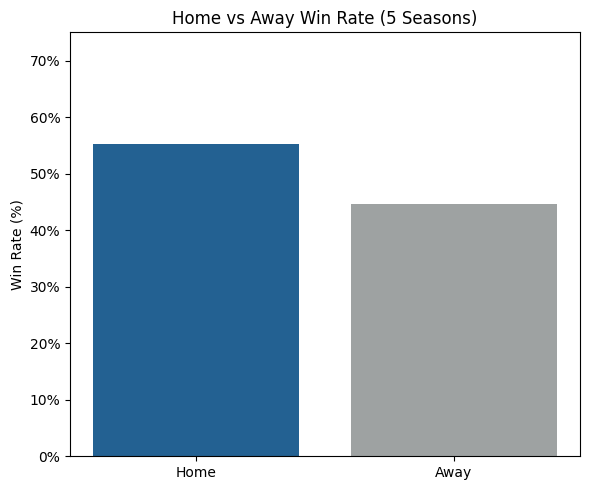

In [80]:
plt.figure(figsize=(6, 5))
plt.bar(["Home", "Away"], [home_win, away_win], color=["#236192", "#9EA2A2"])
plt.title("Home vs Away Win Rate (5 Seasons)")
plt.ylabel("Win Rate (%)")
plt.ylim(0, 0.75)
plt.yticks([0, .10, .20, .30, .40, .50, .60, .70], ["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%"])
plt.tight_layout()
plt.savefig("visualizations/home_vs_away.png", dpi=150)
plt.show()

### Chart 2: Back to Back games vs rested games 

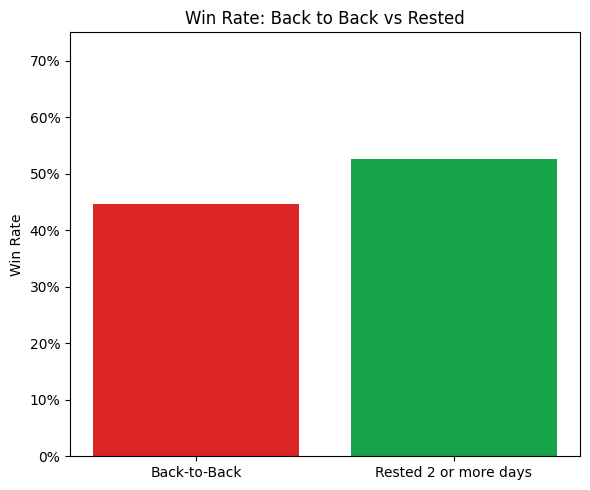

In [76]:
plt.figure(figsize=(6, 5))
plt.bar(["Back-to-Back", "Rested 2 or more days"], [backback_win, rested_win], color=["#dc2626", "#16a34a"])
plt.title("Win Rate: Back to Back vs Rested")
plt.ylabel("Win Rate")
plt.ylim(0, 0.75)
plt.yticks([0, .10, .20, .30, .40, .50, .60, .70], ["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%"])
plt.tight_layout()
plt.savefig("visualizations/rest_days.png", dpi=150)
plt.show()

### Chart 3: Player impact 
> Games where Rudy Gobert or Anthony Edwards played or didnt play  

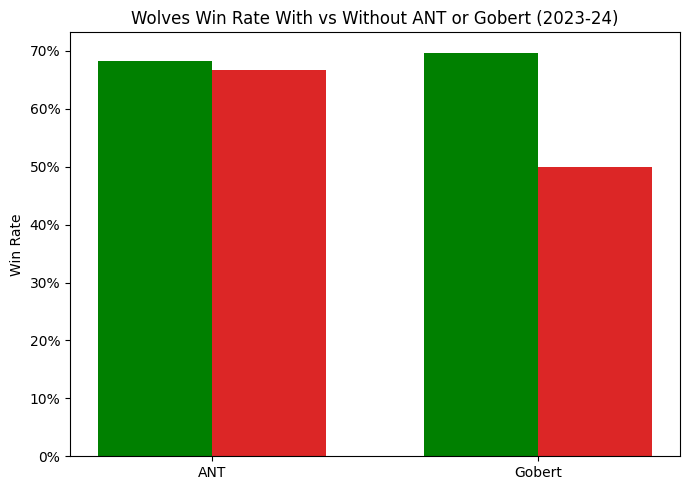

In [75]:
x = np.arange(2)
width = 0.35
withp = [wolves[wolves["ANT_PLAYED"] == 1]["WIN"].mean(), wolves[wolves["GOBERT_PLAYED"] == 1]["WIN"].mean()]
without = [wolves[wolves["ANT_PLAYED"] == 0]["WIN"].mean(), wolves[wolves["GOBERT_PLAYED"] == 0]["WIN"].mean()]

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, withp, width, label="With", color="#008000")
plt.bar(x + width/2, without, width, label="Without", color="#dc2626")
plt.xticks(x, ["ANT", "Gobert"])
plt.title("Wolves Win Rate With vs Without ANT or Gobert (2023-24)")
plt.ylabel("Win Rate")
plt.yticks([0, .10, .20, .30, .40, .50, .60, .70], ["0%", "10%", "20%", "30%", "40%", "50%", "60%", "70%"])
plt.tight_layout()
plt.savefig("visualizations/player_impact.png", dpi=150)
plt.show()


### Chart 4: Scatter Plot point differential 
> A simple point differential scatter plot. Gray dots for every team and a blue dot for the Wolves shows relationship between winning by more points and winning more games

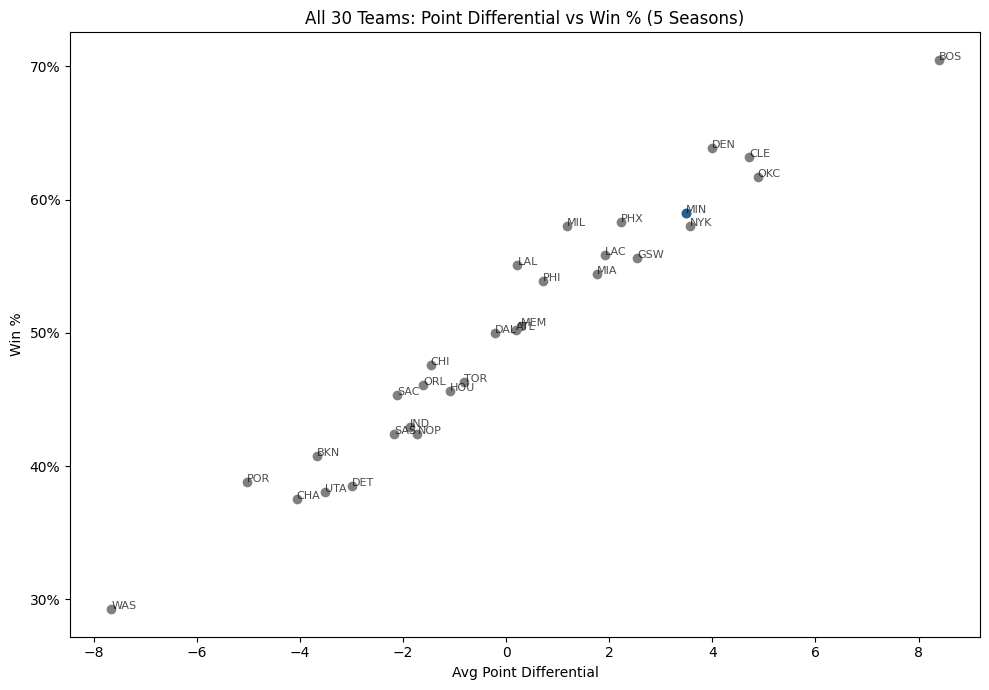

In [ ]:
team_stats = df.groupby("TEAM_ABBREVIATION").agg(win_pct=("WIN", "mean"), net_rating=("POINT_DIFF", "mean")).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(team_stats["net_rating"], team_stats["win_pct"], color="gray")
ax.scatter(team_stats[team_stats["TEAM_ABBREVIATION"] == "MIN"]["net_rating"],
           team_stats[team_stats["TEAM_ABBREVIATION"] == "MIN"]["win_pct"],
           color="#236192")
for _, row in team_stats.iterrows():
    ax.annotate(row["TEAM_ABBREVIATION"], (row["net_rating"], row["win_pct"]), fontsize=8, alpha=0.7)
ax.set_xlabel("Avg Point Differential")
ax.set_ylabel("Win %")
plt.yticks([.30, .40, .50, .60, .70], ["30%", "40%", "50%", "60%", "70%"])
ax.set_title("Point Differential vs Win percentage in 5 Seasons")
plt.tight_layout()
plt.savefig("visualizations/team_scatter.png", dpi=150)
plt.show()

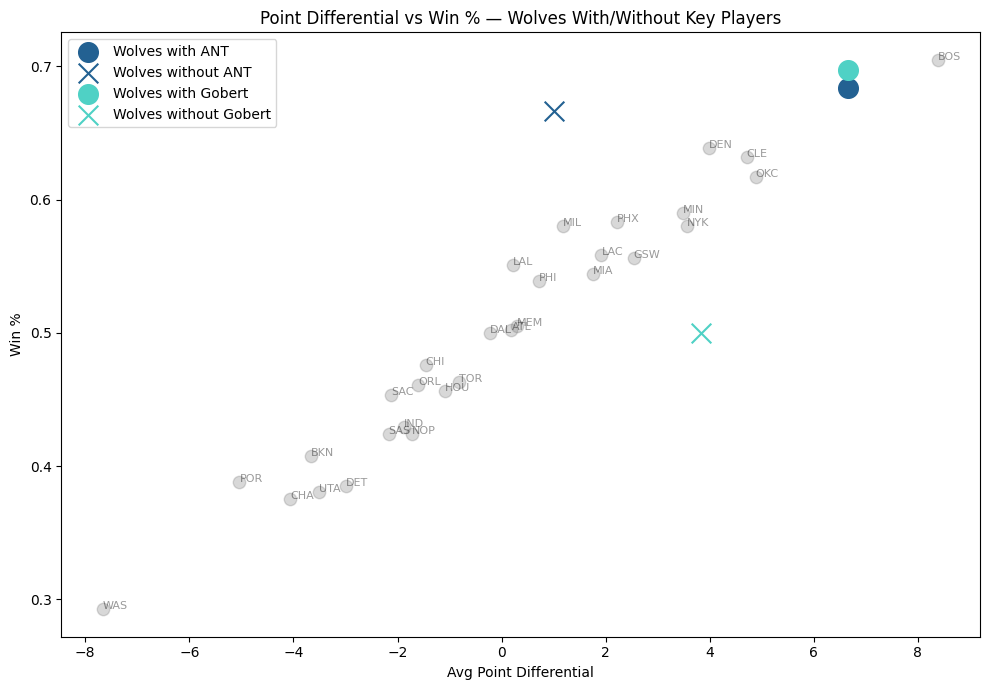

In [89]:
fig, ax = plt.subplots(figsize=(10, 7))

# All 30 teams in background
ax.scatter(team_stats["net_rating"], team_stats["win_pct"], color="gray", alpha=0.3, s=80)

# Wolves with ANT
wolves_with_ant = wolves[wolves["ANT_PLAYED"] == 1]
wolves_without_ant = wolves[wolves["ANT_PLAYED"] == 0]
wolves_with_gobert = wolves[wolves["GOBERT_PLAYED"] == 1]
wolves_without_gobert = wolves[wolves["GOBERT_PLAYED"] == 0]

ax.scatter(wolves_with_ant["POINT_DIFF"].mean(), wolves_with_ant["WIN"].mean(), color="#236192", s=200, zorder=5, label="Wolves with ANT")
ax.scatter(wolves_without_ant["POINT_DIFF"].mean(), wolves_without_ant["WIN"].mean(), color="#236192", s=200, marker="x", zorder=5, label="Wolves without ANT")
ax.scatter(wolves_with_gobert["POINT_DIFF"].mean(), wolves_with_gobert["WIN"].mean(), color="#4fd1c5", s=200, zorder=5, label="Wolves with Gobert")
ax.scatter(wolves_without_gobert["POINT_DIFF"].mean(), wolves_without_gobert["WIN"].mean(), color="#4fd1c5", s=200, marker="x", zorder=5, label="Wolves without Gobert")

for _, row in team_stats.iterrows():
    ax.annotate(row["TEAM_ABBREVIATION"], (row["net_rating"], row["win_pct"]), fontsize=8, alpha=0.4)

ax.set_xlabel("Avg Point Differential")
ax.set_ylabel("Win %")
ax.set_title("Point Differential vs Win % — Wolves With/Without Key Players")
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/scatter_player.png", dpi=150)
plt.show()

---
One Final Breakdown
---
> I was mostly done with collecting and showing data, when I thought what if we throw ALL of a best and worse case scenario together, I wanted to explore another team, but take the same angle, Luke Doncic and the Maverics, Luka is known to be out for large stretches but is one of the best players in the league, lets see what happens when we have all of the best ways to win and the biggest ways to lose from the data

In [95]:
luka_all = []
for season in seasons:
    luka_all.append(playergamelog.PlayerGameLog(player_id=1629029, season=season).get_data_frames()[0])

luka = pd.concat(luka_all, ignore_index=True)
luka.to_csv("data/luka_games.csv", index=False)
print(f"Luka games: {len(luka)}")

Luka games: 315


In [ ]:
luka = pd.read_csv("data/luka_games.csv")

mavs = df[df["TEAM_ABBREVIATION"] == "DAL"].copy()
mavs["LUKA_PLAYED"] = mavs["GAME_ID"].isin(luka["Game_ID"]).astype(int)

luka_best = mavs[(mavs["HOME"] == 1) & 
                 (mavs["REST_DAYS"] >= 2) & 
                 (mavs["LUKA_PLAYED"] == 1)]
luka_worst = mavs[(mavs["HOME"] == 0) & 
                  (mavs["BACK_TO_BACK"] == 1) & 
                  (mavs["LUKA_PLAYED"] == 0)]

print(f"Games with Luka:    {mavs['LUKA_PLAYED'].sum()}")
print(f"Games without Luka: {(mavs['LUKA_PLAYED'] == 0).sum()}")
print(f"Win rate with Luka:    {mavs[mavs['LUKA_PLAYED'] == 1]['WIN'].mean():.2%}")
print(f"Win rate without Luka: {mavs[mavs['LUKA_PLAYED'] == 0]['WIN'].mean():.2%}")
print()
print(f"Best case games: {len(luka_best)} | Win rate: {luka_best['WIN'].mean():.2%} | Point diff: {luka_best['POINT_DIFF'].mean():.2f}")
print(f"Worst case games: {len(luka_worst)} | Win rate: {luka_worst['WIN'].mean():.2%} | Point diff: {luka_worst['POINT_DIFF'].mean():.2f}")

Games with Luka:    227
Games without Luka: 183
Win rate WITH Luka:    59.91%
Win rate WITHOUT Luka: 37.70%

Best case games: 29 | Win rate: 62.07% | Point diff: 5.24
Worst case games: 21 | Win rate: 28.57% | Point diff: -8.81


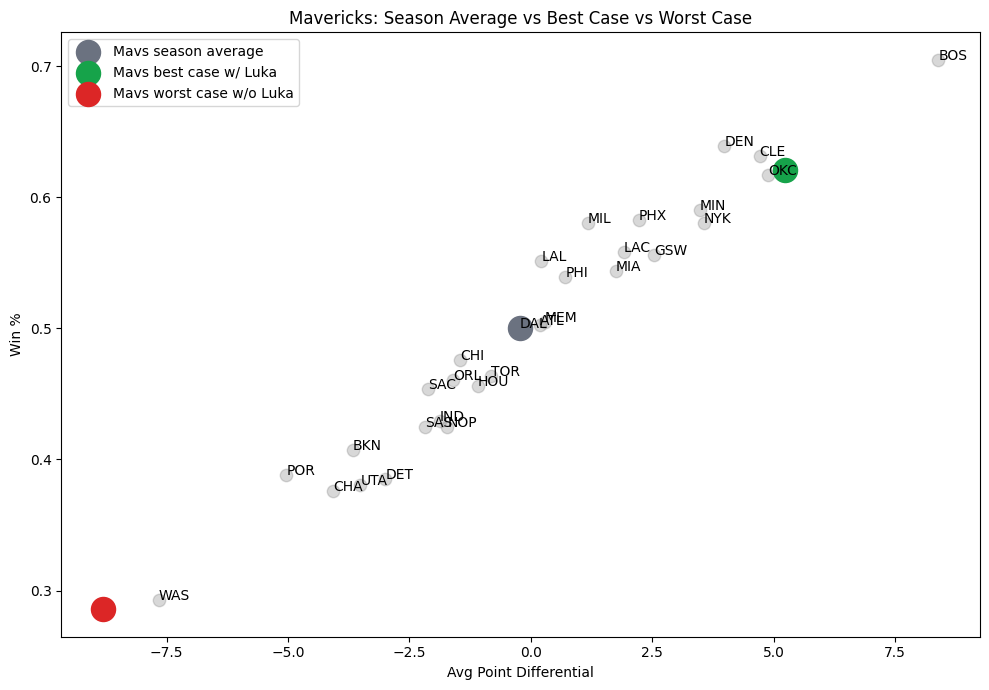

In [103]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(team_stats["net_rating"], team_stats["win_pct"], color="gray", alpha=0.3, s=80)

#avg record
mavs_avg = team_stats[team_stats["TEAM_ABBREVIATION"] == "DAL"]
ax.scatter(mavs_avg["net_rating"], mavs_avg["win_pct"],
           color="#6b7280", s=300, label="Mavs season average")

#best chance
ax.scatter(luka_best["POINT_DIFF"].mean(), luka_best["WIN"].mean(),
           color="#16a34a", s=300, label="Mavs best case w/ Luka")

#worst chance
ax.scatter(luka_worst["POINT_DIFF"].mean(), luka_worst["WIN"].mean(),
           color="#dc2626", s=300, label="Mavs worst case w/o Luka")

for _, row in team_stats.iterrows():
    ax.annotate(row["TEAM_ABBREVIATION"], (row["net_rating"], row["win_pct"]))

ax.set_xlabel("Avg Point Differential")
ax.set_ylabel("Win %")
ax.set_title("Mavericks: Season Average vs Best Case vs Worst Case")
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/luka_full_case.png", dpi=150)
plt.show()